<a href="https://www.kaggle.com/code/lukaspanos/mnist-pca-k-means?scriptVersionId=344267820" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

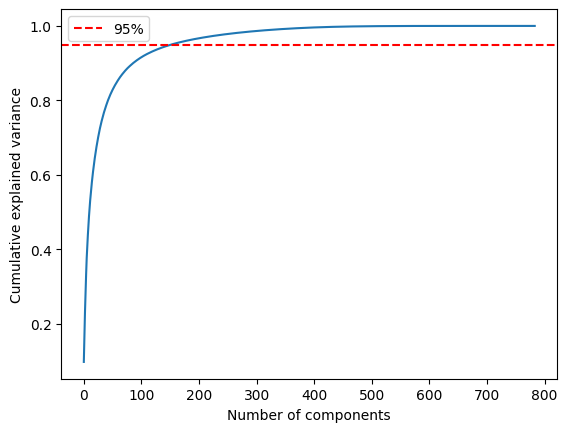

Components for 90%: 87
Components for 95%: 154


In [1]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

train = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
test = pd.read_csv('/kaggle/input/competitions/digit-recognizer/test.csv')

X = train.drop(columns=['label']) / 255.0
y = train['label']

pca = PCA().fit(X)

cum = np.cumsum(pca.explained_variance_ratio_)
plt.plot(cum)
plt.axhline(0.95, color='r', linestyle='--', label='95%')
plt.xlabel('Number of components'); plt.ylabel('Cumulative explained variance')
plt.legend(); plt.show()

print(f"Components for 90%: {np.argmax(cum >= 0.90) + 1}")
print(f"Components for 95%: {np.argmax(cum >= 0.95) + 1}")

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time

pca154 = PCA(n_components=154)
X_87 = pca154.fit_transform(X)

X_tr, X_te, y_tr, y_te = train_test_split(X_87, y, test_size=0.2, random_state=42, stratify=y)

start = time.time()
logreg = LogisticRegression(max_iter=200)
logreg.fit(X_tr, y_tr)
print(f"Accuracy on 154 components: {accuracy_score(y_te, logreg.predict(X_te)):.4f}")
print(f"Train time: {time.time() - start:.1f}s")

Accuracy on 154 components: 0.9143
Train time: 7.6s


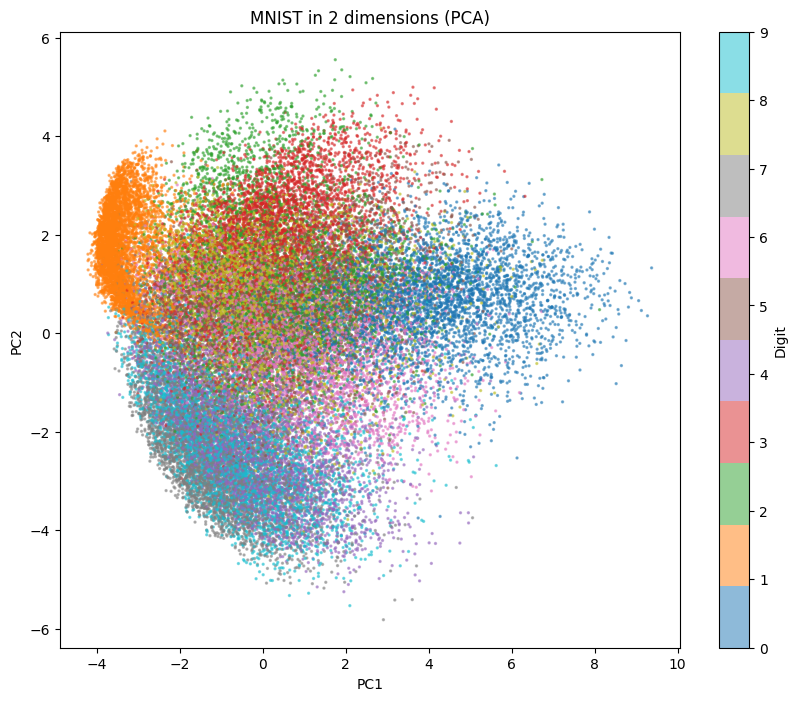

In [3]:
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', s=2, alpha=0.5)
plt.colorbar(scatter, label='Digit')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('MNIST in 2 dimensions (PCA)')
plt.show()

In [4]:
km = KMeans(n_clusters=10, n_init=10, random_state=42)
clusters = km.fit_predict(X_87)

ct = pd.crosstab(clusters, y)
print(ct)

label     0     1     2     3     4     5     6     7     8     9
row_0                                                            
0      1712     0    69    86     7   167    94     9    26    17
1        23     6   124   122  2279   242    55  1309   127  2111
2         9     3  2911   151    26    12    49    31    34     6
3       129     5   144    44   131    73  3420     5    34    12
4       120     8   112   762    13  1079    63     6  2457    51
5         8     4    50    34  1295   236     2  2604   127  1676
6      1981     0     8    11    10    49    84     9    26    32
7         1  2650   237   286    94   110   190   212   176   143
8       138     4   231  2788     0  1260    19     4   768    51
9        11  2004   291    67   217   567   161   212   288    89
